This notebook will serve to correctly determine if our cows are indeed selecting low angle slopes as resting sites. We will check the differences in concavity and low angularity between the cluster distribution and a random distribution in the valley.


In [1]:
import rasterio

path = "../Data/catllar2.tif"

with rasterio.open(path) as ds:
    print("CRS:", ds.crs)
    print("Resolution:", ds.res)      # should be (25, 25)
    print("Bounds:", ds.bounds)
    print("NoData:", ds.nodata)
    print("Shape:", ds.height, ds.width)

    data = ds.read(1)
    print("Elevation min/max:", data.min(), data.max())

CRS: PROJCS["ETRS89 / UTM zone 31N (N-E)",GEOGCS["ETRS89",DATUM["European_Terrestrial_Reference_System_1989",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6258"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4258"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3043"]]
Resolution: (25.0, 25.00000000001129)
Bounds: BoundingBox(left=433404.0, bottom=4687173.999999996, right=443429.0, top=4695424.0)
NoData: None
Shape: 330 401
Elevation min/max: 1070.2246 2712.1924


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

with rasterio.open(path) as ds:
    z = ds.read(1).astype(float)
    transform = ds.transform
    nodata = ds.nodata
    extent = [ds.bounds.left, ds.bounds.right, ds.bounds.bottom, ds.bounds.top]

# Mask NoData
z[z == nodata] = np.nan

# Optional smoothing (recommended for curvature)
z = gaussian_filter(z, sigma=1)

# Pixel size (meters)
dx = transform.a
dy = -transform.e

# First derivatives
dz_dx, dz_dy = np.gradient(z, dx, dy)

# Slope (degrees)
slope = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))

# Second derivatives → curvature
d2z_dx2 = np.gradient(dz_dx, dx, axis=1)
d2z_dy2 = np.gradient(dz_dy, dy, axis=0)

curvature = d2z_dx2 + d2z_dy2


In [3]:
from rasterio.features import geometry_mask
import geopandas as gpd
"""
We make a mask for the points so it is easier to later determine the sampling for the null model.
"""
polygon_path = "../Data/study_area.gpkg"  # or .shp
poly = gpd.read_file(polygon_path)


poly = poly.to_crs(ds.crs)

mask = geometry_mask(
    [feature["geometry"] for feature in poly.__geo_interface__["features"]],
    out_shape=z.shape,
    transform=transform,
    invert=True  # pixels inside polygon = True
)

z_masked = np.where(mask,z,np.nan)
slope_masked = np.where(mask, slope, np.nan)
curvature_masked = np.where(mask, curvature, np.nan)



/Users/jan/Desktop/Uni/Biologia/Article/venv/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry=None, index=1, value=1, error=TypeError("'NoneType' object is not subscriptable")
  _rasterize(


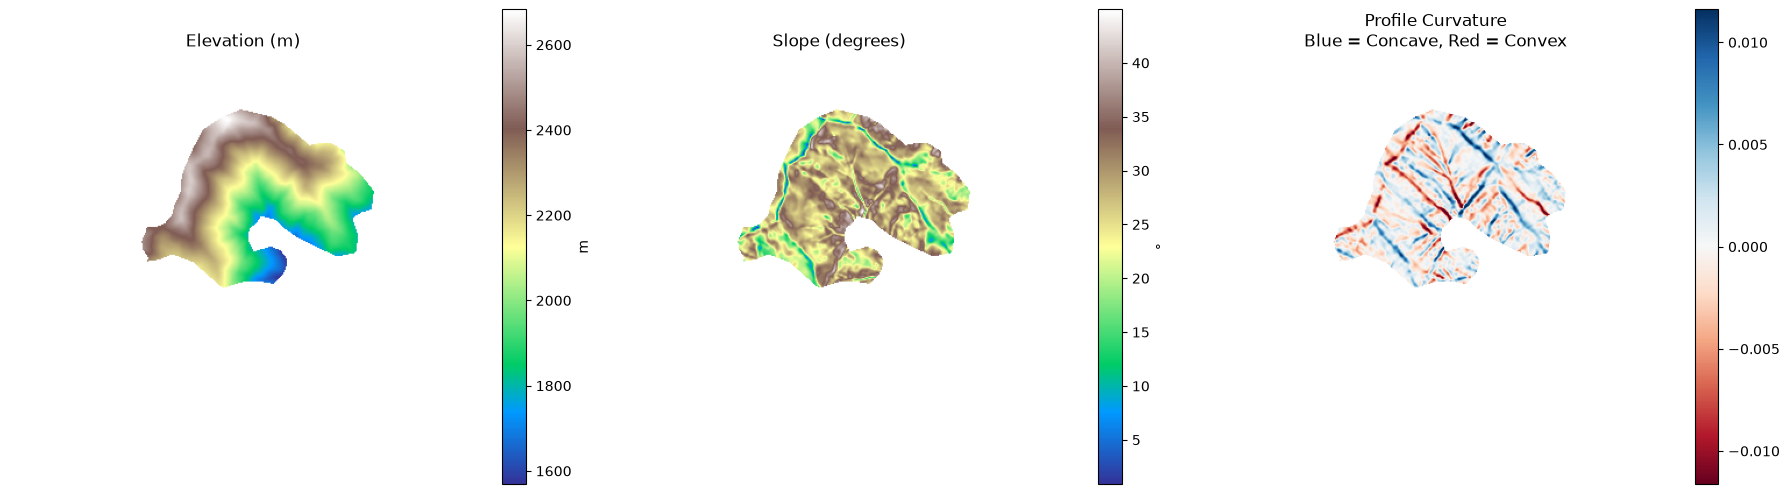

In [4]:
# Robust limits for curvature visualization. Just to get an idea of the area. no specific need. 

curv_vmax = np.nanpercentile(np.abs(curvature), 98)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Elevation ---
im0 = axes[0].imshow(z_masked, cmap="terrain")
axes[0].set_title("Elevation (m)")
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.046, label="m")

# --- Slope ---
im1 = axes[1].imshow(slope_masked, cmap="terrain")
axes[1].set_title("Slope (degrees)")
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.046, label="°")

# --- Curvature ---
im2 = axes[2].imshow(
    curvature_masked,
    cmap="RdBu",
    vmin=-curv_vmax,
    vmax=curv_vmax
)
axes[2].set_title("Profile Curvature\nBlue = Concave, Red = Convex")
axes[2].axis("off")
fig.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

In [5]:
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
from rasterio.transform import rowcol


df = pd.read_csv("../Data/dades_clusters.csv")  # columns: lon, lat
print(df["id"].nunique())
df_filtered = df[df["cluster_fi"] != -1].copy()

gdf = gpd.GeoDataFrame(
    df_filtered,
    geometry=[Point(xy) for xy in zip(df_filtered.lng, df_filtered.lat)],
    crs="EPSG:4326"
)

gdf_utm = gdf.to_crs("EPSG:25831")

rows = []
cols = []

for geom in gdf_utm.geometry:
    r, c = rowcol(transform, geom.x, geom.y)
    rows.append(r)
    cols.append(c)

rows = np.array(rows)
cols = np.array(cols)

valid = (
    (rows >= 0) & (rows < slope.shape[0]) &
    (cols >= 0) & (cols < slope.shape[1])
)

gdf_utm["slope_deg"] = np.nan
gdf_utm["curvature"] = np.nan

gdf_utm.loc[valid, "slope_deg"] = slope[rows[valid], cols[valid]]
gdf_utm.loc[valid, "curvature"] = curvature[rows[valid], cols[valid]]

144


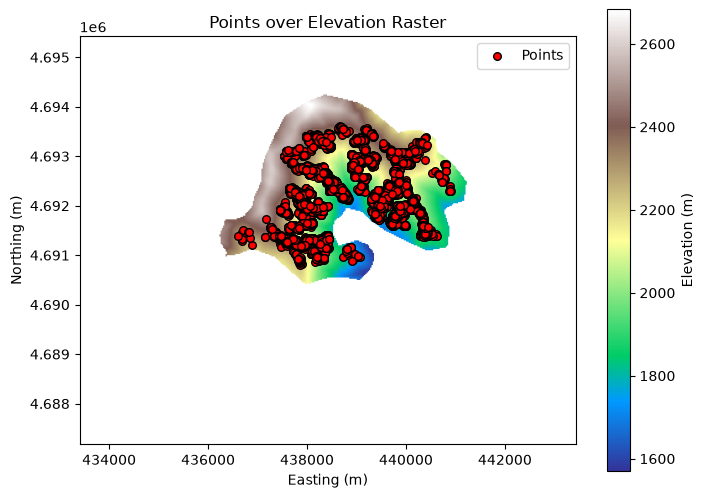

In [6]:
plt.figure(figsize=(8, 6))

# Plot raster
plt.imshow(z_masked, extent=extent, cmap="terrain")
plt.colorbar(label="Elevation (m)")

# Overlay points
plt.scatter(
    gdf_utm.geometry.x, 
    gdf_utm.geometry.y, 
    color="red", 
    edgecolor="k", 
    s=30, 
    label="Points"
)

plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("Points over Elevation Raster")
plt.legend()
plt.show()

In [7]:
import random
"""
Single sampling and statistical tests.
"""
def generate_random_points_in_polygon(polygon_gdf, n_points):
    points = []
    bounds = polygon_gdf.total_bounds  # [minx, miny, maxx, maxy]
    minx, miny, maxx, maxy = bounds

    while len(points) < n_points:
        x = random.uniform(minx, maxx)
        y = random.uniform(miny, maxy)
        p = Point(x, y)
        if polygon_gdf.contains(p).any():
            points.append(p)
    return gpd.GeoDataFrame(geometry=points, crs=polygon_gdf.crs)

n_points = len(gdf_utm)  # same number as your filtered points
gdf_random = generate_random_points_in_polygon(poly, n_points)

In [8]:
coords = [(p.x, p.y) for p in gdf_random.geometry]
rows, cols = zip(*[rowcol(transform, x, y) for x, y in coords])

rows = np.array(rows)
cols = np.array(cols)

# Initialize columns
gdf_random["slope_deg"] = np.nan
gdf_random["curvature"] = np.nan

valid = (
    (rows >= 0) & (rows < slope_masked.shape[0]) &
    (cols >= 0) & (cols < slope_masked.shape[1])
)

gdf_random.loc[valid, "slope_deg"] = slope_masked[rows[valid], cols[valid]]
gdf_random.loc[valid, "curvature"] = curvature_masked[rows[valid], cols[valid]]

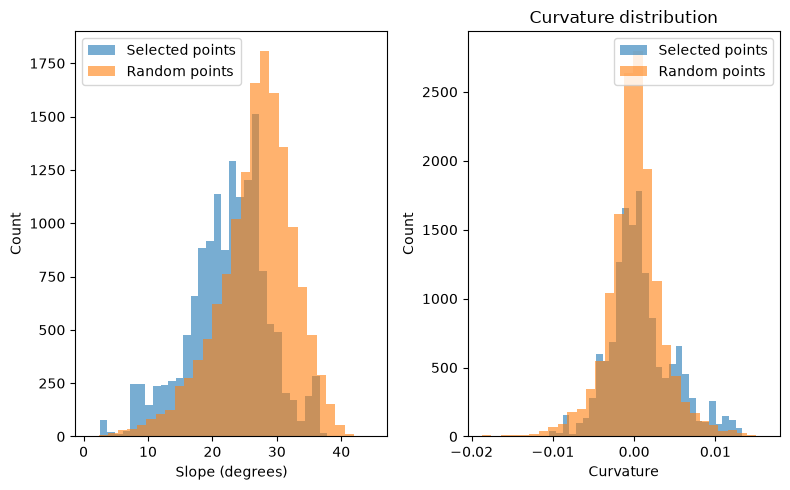

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

# Slope
plt.subplot(1,2,1)
plt.hist(gdf_utm["slope_deg"].dropna(), bins=30, alpha=0.6, label="Selected points")
plt.hist(gdf_random["slope_deg"].dropna(), bins=30, alpha=0.6, label="Random points")
plt.xlabel("Slope (degrees)")
plt.ylabel("Count")
#plt.title("Slope distribution")
plt.legend()

# Curvature
plt.subplot(1,2,2)
plt.hist(gdf_utm["curvature"].dropna(), bins=30, alpha=0.6, label="Selected points")
plt.hist(gdf_random["curvature"].dropna(), bins=30, alpha=0.6, label="Random points")
plt.xlabel("Curvature")
plt.ylabel("Count")
plt.title("Curvature distribution")
plt.legend()

plt.tight_layout()
plt.show()

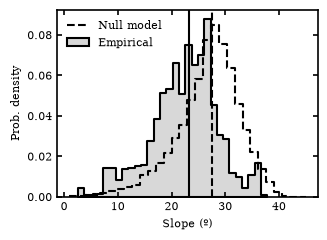

23.21758814425038
27.489956208046443
-4.272368063796062


In [11]:
import seaborn as sns
from utilities import set_article_style

set_article_style()

slope_selected = gdf_utm["slope_deg"].dropna()
slope_random = gdf_random["slope_deg"].dropna()

plt.figure()

sns.histplot(
    slope_random,
    bins=30,
    stat="density",
    element="step",
    fill=False,          # No fill makes the dash stand out
    ls="--",             # Dashed line
    color="black",       # Keeping it professional black
    label="Null model",
    lw=1.5
)

# 2. Observed Locations (Solid, Gray Fill)
sns.histplot(
    slope_selected,
    bins=30,
    stat="density",    
    element="step",
    fill=True,
    color="gray",        # Using gray fill for the primary data
    alpha=0.3,           # Light enough to see the grid/dashed line behind it
    edgecolor="black",   # Solid black border
    ls="-",              # Solid line
    label="Empirical",
    lw=1.5
)

# 3. Median Lines
plt.axvline(slope_selected.median(), color="black", linestyle="-", linewidth=1.5)
plt.axvline(slope_random.median(), color="black", linestyle="--", linewidth=1.5)

plt.xlabel("Slope (º)")
plt.ylabel("Prob. density")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("../Plots/slope.pdf")
plt.show()

print(slope_selected.median())
print(slope_random.median())
print(slope_selected.median()-slope_random.median())

In [12]:
from scipy.stats import ks_2samp

slope_selected = gdf_utm["slope_deg"].dropna()
slope_random = gdf_random["slope_deg"].dropna()

curvature_selected = gdf_utm["curvature"].dropna()
curvature_random = gdf_random["curvature"].dropna()

ks_slope = ks_2samp(slope_selected, slope_random)
print("Slope KS test:")
print(f"Statistic: {ks_slope.statistic:.3f}, p-value: {ks_slope.pvalue:.8f}")

# Curvature
ks_curv = ks_2samp(curvature_selected, curvature_random)
print("\nCurvature KS test:")
print(f"Statistic: {ks_curv.statistic:.3f}, p-value: {ks_curv.pvalue:.8f}")

Slope KS test:
Statistic: 0.339, p-value: 0.00000000

Curvature KS test:
Statistic: 0.106, p-value: 0.00000000


In [13]:
from scipy.stats import mannwhitneyu

# Slope
u_slope, p_slope = mannwhitneyu(slope_selected, slope_random, alternative="two-sided")
print(f"Slope Mann–Whitney U: statistic={u_slope}, p={p_slope:.8f}")

# Curvature
u_curv, p_curv = mannwhitneyu(curvature_selected, curvature_random, alternative="two-sided")
print(f"Curvature Mann–Whitney U: statistic={u_curv}, p={p_curv:.8f}")

# Median for your filtered points
slope_median_selected = gdf_utm["slope_deg"].median()
curv_median_selected = gdf_utm["curvature"].median()

print(f"Median slope (selected points): {slope_median_selected:.2f}°")
print(f"Median curvature (selected points): {curv_median_selected:.5f}")

# Median for random points
slope_median_random = gdf_random["slope_deg"].median()
curv_median_random = gdf_random["curvature"].median()

print(f"Median slope (random points): {slope_median_random:.2f}°")
print(f"Median curvature (random points): {curv_median_random:.5f}")

Slope Mann–Whitney U: statistic=61747390.5, p=0.00000000
Curvature Mann–Whitney U: statistic=114174793.5, p=0.00000000
Median slope (selected points): 23.22°
Median curvature (selected points): 0.00035
Median slope (random points): 27.49°
Median curvature (random points): 0.00008


In [14]:
def permutation_median_test(x, y, n_permutations=10000):
    observed_diff = np.median(x) - np.median(y)
    combined = np.concatenate([x, y])
    n_x = len(x)

    perm_diffs = np.zeros(n_permutations)
    for i in range(n_permutations):
        np.random.shuffle(combined)
        perm_x = combined[:n_x]
        perm_y = combined[n_x:]
        perm_diffs[i] = np.median(perm_x) - np.median(perm_y)

    p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
    return observed_diff, p_value

# Run test
diff_median, p_perm = permutation_median_test(
    slope_selected.values,
    slope_random.values
)

print(f"Observed median difference: {diff_median:.2f}°")
print(f"Permutation test p-value: {p_perm:.8f}")

Observed median difference: -4.27°
Permutation test p-value: 0.00000000


In [15]:
import numpy as np
import matplotlib.pyplot as plt

def monte_carlo_landscape_test(empirical_vals, raster_masked, n_iterations=1000):
    """
    Compares the empirical median against a distribution of medians 
    drawn from M random sub-sets of the background landscape.
    """
    # 1. Extract all valid background pixels (the whole valley)
    background_pixels = raster_masked[~np.isnan(raster_masked)]
    
    empirical_median = np.median(empirical_vals)
    n_samples = len(empirical_vals)
    
    # 2. Resample N points from the background M times
    null_medians = np.zeros(n_iterations)
    for i in range(n_iterations):
        sample = np.random.choice(background_pixels, size=n_samples, replace=True)
        null_medians[i] = np.median(sample)
        
    # 3. Calculate Monte Carlo p-value (testing if empirical median is smaller than background)
    p_value_one_tailed = (np.sum(null_medians <= empirical_median) + 1) / (n_iterations + 1)
    
    # 95% Confidence Interval for expected background median
    ci_lower, ci_upper = np.percentile(null_medians, [2.5, 97.5])
    
    return empirical_median, null_medians, p_value_one_tailed, (ci_lower, ci_upper)

# Run Monte Carlo test for Slope
slope_emp = gdf_utm["slope_deg"].dropna().values
emp_slope_med, null_slope_meds, p_val_slope, ci_slope = monte_carlo_landscape_test(
    slope_emp, slope_masked, n_iterations=1000
)

print(f"Empirical Median Slope: {emp_slope_med:.2f}°")
print(f"Expected Valley Null Median (95% CI): [{ci_slope[0]:.2f}°, {ci_slope[1]:.2f}°]")
print(f"Monte Carlo Null Test p-value: p = {p_val_slope:.6f}")

Empirical Median Slope: 23.22°
Expected Valley Null Median (95% CI): [27.37°, 27.56°]
Monte Carlo Null Test p-value: p = 0.000999


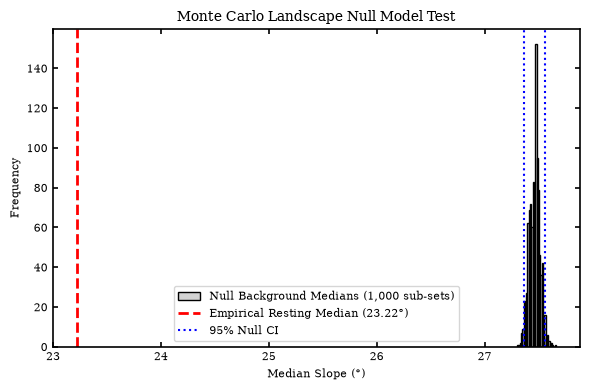

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))

# Plot distribution of null medians
ax.hist(null_slope_meds, bins=30, color="lightgray", edgecolor="black", label="Null Background Medians (1,000 sub-sets)")

# Plot empirical median
ax.axvline(emp_slope_med, color="red", linestyle="--", linewidth=2, label=f"Empirical Resting Median ({emp_slope_med:.2f}°)")

# Plot 95% CI of background
ax.axvline(ci_slope[0], color="blue", linestyle=":", label="95% Null CI")
ax.axvline(ci_slope[1], color="blue", linestyle=":")

ax.set_xlabel("Median Slope (°)")
ax.set_ylabel("Frequency")
ax.set_title("Monte Carlo Landscape Null Model Test")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()